In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from sklearn.model_selection import learning_curve as sk_learning_curve

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score
import plotly.express as px

In [66]:
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng') # New version for some NLTK releases

# # Required for Tokenization and Lemmatization
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

Dataset Check

In [67]:
data = pd.read_csv('combined_dataset_final.csv')
print(data.head())

                            Genre  \
0                 Online learning   
1            Athletics and sports   
2  Academic Support and Resources   
3               Food and Cantines   
4               Food and Cantines   

                                             Reports  Age   Gpa  Year  Count  \
0          The classroom projectors doesnt work well   26  2.80     2      1   
1   The athletic department should prioritize the...   22  2.98     4      1   
2  The library catalogue system is outdated and h...   22  0.93     3      1   
3  The canteen does not display any allergen info...   16  1.72     5      1   
4  The dining area near the science block has no ...   18  1.72     4      1   

  Gender   Nationality  
0      M      Malaysia  
1      M        Soudan  
2      F         India  
3      F       Nigeria  
4      M  Saudi Arabia  


In [68]:
print(data.shape)

(6225, 8)


In [69]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 6225 entries, 0 to 6224
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Genre        6225 non-null   str    
 1   Reports      6225 non-null   str    
 2   Age          6225 non-null   int64  
 3   Gpa          6225 non-null   float64
 4   Year         6225 non-null   int64  
 5   Count        6225 non-null   int64  
 6   Gender       6225 non-null   str    
 7   Nationality  6225 non-null   str    
dtypes: float64(1), int64(3), str(4)
memory usage: 1.2 MB
None


In [70]:
#Dropping unused columns

cols_to_drop = ['Age', 'Gpa', 'Year', 'Count', 'Gender', 'Nationality']

data = data.drop(columns=(cols_to_drop))

data.head()

,Genre,Reports
0,Online learning,The classroom projectors doesnt work well
1,Athletics and sports,The athletic department should prioritize the...
2,Academic Support and Resources,The library catalogue system is outdated and h...
3,Food and Cantines,The canteen does not display any allergen info...
4,Food and Cantines,The dining area near the science block has no ...


In [71]:
data['Genre'] = data['Genre'].replace('Activities and Travelling', 'Student Activities')
data['Genre'] = data['Genre'].replace('Career opportunities', 'Internship Opportunities')

EDA

In [72]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6225 entries, 0 to 6224
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Genre    6225 non-null   str  
 1   Reports  6225 non-null   str  
dtypes: str(2)
memory usage: 877.5 KB


In [73]:
data.describe(include=object)

C:\Users\rmksu\AppData\Local\Temp\ipykernel_8308\3757873171.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=object)


,Genre,Reports
count,6225,6225
unique,11,2501
top,Academic Support and Resources,There are no creative arts performance spaces ...
freq,691,20


In [74]:
missing_summary = pd.DataFrame({
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage' : (data.isnull().sum().mean() *100).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
Genre,0,0.0
Reports,0,0.0


Genre distribution:
Genre
Academic Support and Resources       691
Housing and Transportation           660
Athletics and sports                 590
Health and Well-being Support        585
Internship Opportunities             572
Student Activities                   571
International student experiences    567
Online learning                      536
Student Affairs                      515
Financial Support                    505
Food and Cantines                    433
Name: count, dtype: int64

Total records: 6225
Total genres: 11


C:\Users\rmksu\AppData\Local\Temp\ipykernel_8308\1668236127.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')


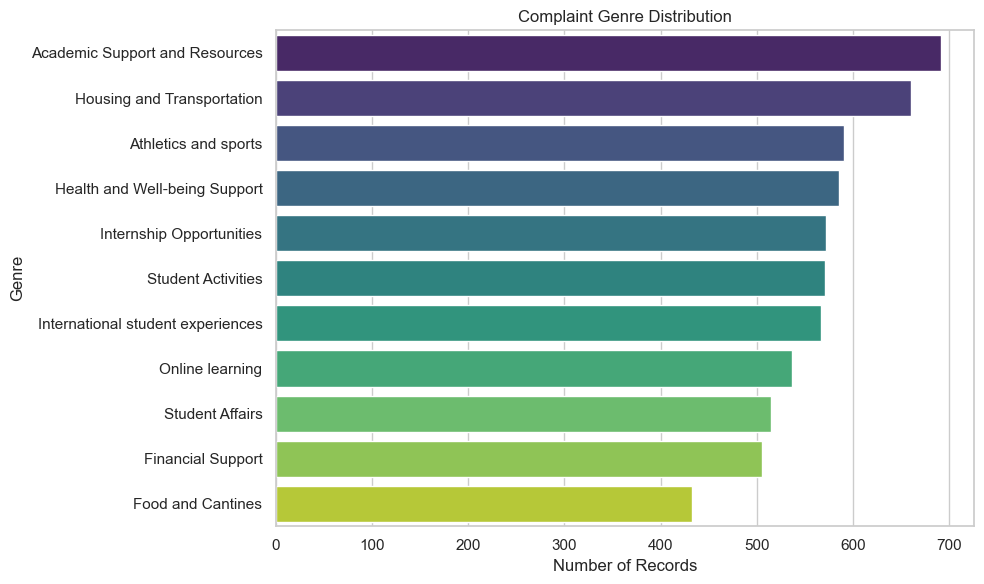

In [75]:
# Genre count
genre_counts = data['Genre'].value_counts()

print("Genre distribution:")
print(genre_counts)
print(f"\nTotal records: {len(data)}")
print(f"Total genres: {data['Genre'].nunique()}")

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Complaint Genre Distribution')
plt.xlabel('Number of Records')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

In [76]:
x = data['Reports']
y = data['Genre']
# Split the data (80% training, 20% testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


Preprocessing

In [77]:
#Lemmatizing

lemmatizer = WordNetLemmatizer()

def get_label(tag):
    if tag.startswith('j'):
        return 'a'
    elif tag.startswith('r') or tag.startswith('v') or tag.startswith('n'):
        return tag[0]
    else:
        return 'n'
    
def lemmatizing(word_list):
    lemma_list = []
    tagged = pos_tag(word_list)

    for word, tag in tagged:
        label = get_label(tag.lower())
        if label:
            result = lemmatizer.lemmatize(word, label)
            lemma_list.append(result)
        else:
            result = lemmatizer.lemmatize(word)
            lemma_list.append(result)
            
    return lemma_list

def preprocessing(sentence):
    eng_stopwords = set(stopwords.words('english'))
    punctuations = set(string.punctuation)

    sentence = sentence.lower()

    word_list = word_tokenize(sentence)

    filtered = [
        token for token in word_list
        if token not in eng_stopwords
        and token not in punctuations
        and token.isalpha()
    ]

    return lemmatizing(filtered)


In [78]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [79]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tfidf_params = dict(
    tokenizer=preprocessing,
    ngram_range=(1, 2),
    max_features=5000,  
    max_df=0.85,
)

models = {
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   MultinomialNB(alpha=1.5))
    ]),


    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LogisticRegression(
            C=0.1,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
        ))
    ]),

    "Linear SVC": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LinearSVC(
            C=0.1,
            max_iter=5000,
            class_weight="balanced"
        ))
    ]),


    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=8,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42
        ))
    ]),
}


In [80]:
results_summary = {}

for name, model in models.items():
    print(f"  {name}")
    model.fit(x_train, y_train)

    # Test performance
    y_pred = model.predict(x_test)
    print("[Test Set Report]")
    print(classification_report(y_test, y_pred))

    train_f1 = f1_score(y_train, model.predict(x_train), average="macro")

    cv_scores = cross_val_score(model, x_train, y_train, cv=skf, scoring="f1_macro")
    cv_mean   = cv_scores.mean()
    test_f1   = f1_score(y_test, y_pred, average="macro")
    gap       = train_f1 - cv_mean

    print(f"  Train F1 (macro):       {train_f1:.4f}")
    print(f"  CV F1   (macro):        {cv_mean:.4f}  (+/- {cv_scores.std():.4f})")
    print(f"  Test F1 (macro):        {test_f1:.4f}")
    flag = "<-- Good (gap < 0.05)" if gap < 0.05 else "<-- Overfitting"
    print(f"  Overfit Gap (Train-CV): {gap:.4f}  {flag}")

    results_summary[name] = {
        "Train F1": train_f1,
        "CV F1":    cv_mean,
        "Test F1":  test_f1,
        "Gap":      gap,
    }


  Naive Bayes


C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[Test Set Report]
                                   precision    recall  f1-score   support

   Academic Support and Resources       0.78      0.87      0.82       138
             Athletics and sports       0.98      0.99      0.99       118
                Financial Support       0.84      0.83      0.84       101
                Food and Cantines       1.00      0.98      0.99        87
    Health and Well-being Support       0.97      0.95      0.96       117
       Housing and Transportation       0.74      0.97      0.84       132
International student experiences       0.97      0.98      0.98       113
         Internship Opportunities       0.97      0.98      0.97       115
                  Online learning       0.95      0.76      0.84       107
               Student Activities       0.98      0.96      0.97       114
                  Student Affairs       0.93      0.65      0.77       103

                         accuracy                           0.90      1245
     

C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\

  Train F1 (macro):       0.9482
  CV F1   (macro):        0.9150  (+/- 0.0091)
  Test F1 (macro):        0.9055
  Overfit Gap (Train-CV): 0.0332  <-- Good (gap < 0.05)
  Logistic Regression


...

  Train F1 (macro):       0.9776
  CV F1   (macro):        0.9390  (+/- 0.0074)
  Test F1 (macro):        0.9320
  Overfit Gap (Train-CV): 0.0386  <-- Good (gap < 0.05)
  Random Forest


C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


[Test Set Report]
                                   precision    recall  f1-score   support

   Academic Support and Resources       0.66      0.56      0.61       138
             Athletics and sports       0.96      0.90      0.93       118
                Financial Support       0.83      0.69      0.76       101
                Food and Cantines       0.83      0.99      0.90        87
    Health and Well-being Support       0.86      0.70      0.77       117
       Housing and Transportation       0.60      0.86      0.70       132
International student experiences       0.93      0.88      0.90       113
         Internship Opportunities       0.90      1.00      0.95       115
                  Online learning       0.69      0.70      0.70       107
               Student Activities       0.93      0.89      0.91       114
                  Student Affairs       0.55      0.50      0.53       103

                         accuracy                           0.78      1245
     

C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\

  Train F1 (macro):       0.8198
  CV F1   (macro):        0.7880  (+/- 0.0138)
  Test F1 (macro):        0.7867
  Overfit Gap (Train-CV): 0.0318  <-- Good (gap < 0.05)


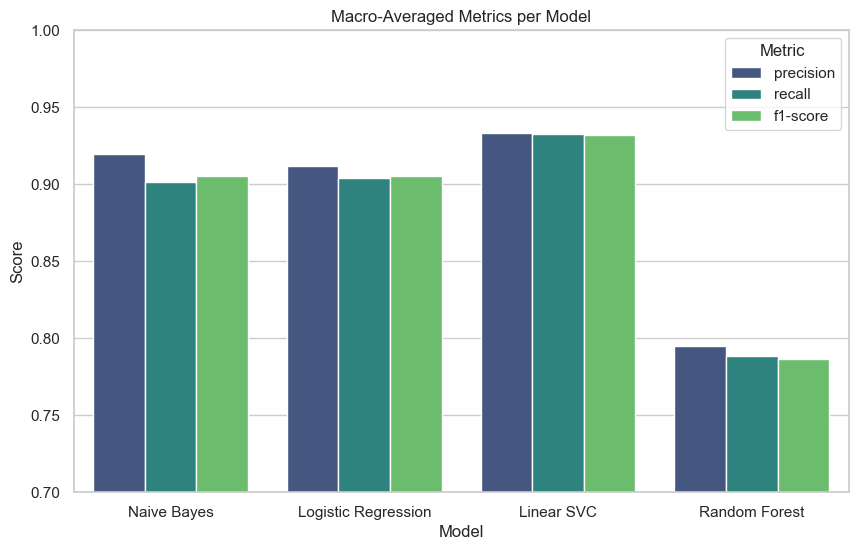

                 Model  precision    recall  f1-score
0          Naive Bayes   0.919394  0.901522  0.905476
1  Logistic Regression   0.911664  0.904208  0.905612
2           Linear SVC   0.933256  0.932738  0.932044
3        Random Forest   0.795210  0.788309  0.786713


In [81]:
macro_metrics_list = []

for name, model in models.items():
    y_pred = model.predict(x_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    macro_avg = report['macro avg']
    
    macro_avg['Model'] = name
    macro_metrics_list.append(macro_avg)

df_macro = pd.DataFrame(macro_metrics_list)

df_melted = df_macro.melt(id_vars='Model', value_vars=['precision', 'recall', 'f1-score'], 
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Macro-Averaged Metrics per Model')
plt.ylim(0.7, 1.0)
plt.show()

print(df_macro[['Model', 'precision', 'recall', 'f1-score']])

In [82]:
test_data = pd.read_csv('test_dataset_1000.csv')
test_data['Genre'] = test_data['Genre'].replace('Activities and Travelling', 'Student Activities')
test_data['Genre'] = test_data['Genre'].replace('Career opportunities', 'Internship Opportunities')
x_test_new = test_data['Reports']
y_test_new = test_data['Genre']

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    y_pred = model.predict(x_test_new)
    print(classification_report(y_test_new, y_pred))


  Naive Bayes
                                   precision    recall  f1-score   support

   Academic Support and Resources       0.84      0.76      0.80        90
             Athletics and sports       0.75      0.95      0.83        91
                Financial Support       0.94      0.84      0.89        92
                Food and Cantines       0.93      0.84      0.88        92
    Health and Well-being Support       0.89      0.94      0.92        90
       Housing and Transportation       0.89      0.93      0.91        91
International student experiences       0.81      0.96      0.88        90
         Internship Opportunities       0.84      1.00      0.92        92
                  Online learning       0.93      0.80      0.86        92
               Student Activities       0.75      0.88      0.81        90
                  Student Affairs       0.88      0.47      0.61        90

                         accuracy                           0.85      1000
        

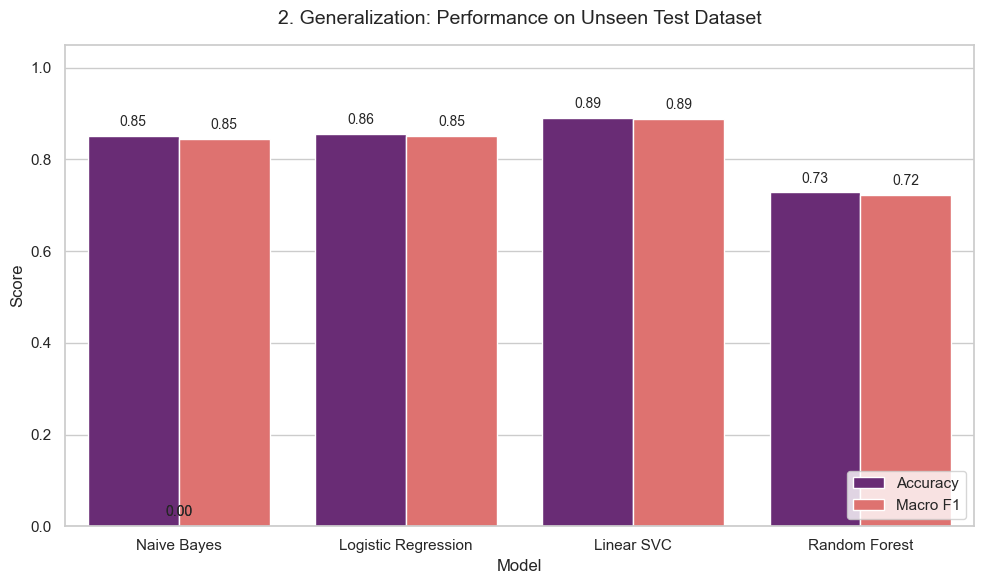

C:\Users\rmksu\AppData\Local\Temp\ipykernel_8308\4195777235.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df3, x='F1-Score', y='Category', palette='Blues_r')


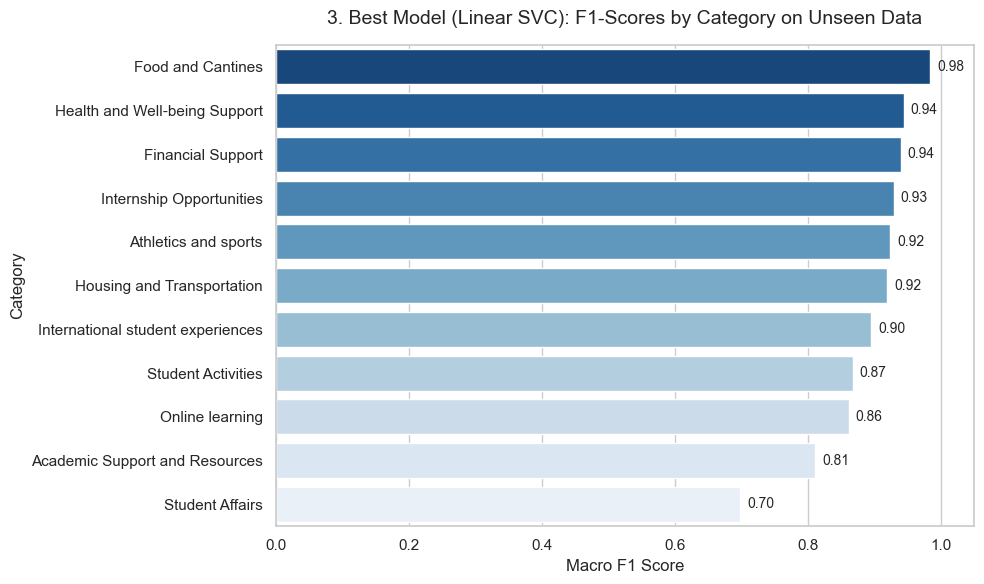

In [83]:
from sklearn.metrics import accuracy_score

unseen_results = {}
unseen_per_class_svc = None

for name, model in models.items():
    y_pred = model.predict(x_test_new)
    acc = accuracy_score(y_test_new, y_pred)
    report = classification_report(y_test_new, y_pred, output_dict=True)
    macro_f1 = report['macro avg']['f1-score']
    unseen_results[name] = {'Accuracy': acc, 'Macro F1': macro_f1}

    if name == 'Linear SVC':
        unseen_per_class_svc = report 

models_list = list(unseen_results.keys())
new_test_acc = [unseen_results[m]['Accuracy'] for m in models_list]
new_test_f1  = [unseen_results[m]['Macro F1'] for m in models_list]

df2 = pd.DataFrame({
    'Model': models_list * 2,
    'Metric': ['Accuracy']*len(models_list) + ['Macro F1']*len(models_list),
    'Score': new_test_acc + new_test_f1
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df2, x='Model', y='Score', hue='Metric', palette='magma')
plt.title('2. Generalization: Performance on Unseen Test Dataset', fontsize=14, pad=15)
plt.ylim(0.0, 1.05)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}",
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', xytext=(0, 5),
                       textcoords='offset points', fontsize=10)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

classes = [c for c in unseen_per_class_svc.keys() if c not in ('accuracy', 'macro avg', 'weighted avg')]
svc_f1  = [unseen_per_class_svc[c]['f1-score'] for c in classes]

df3 = pd.DataFrame({'Category': classes, 'F1-Score': svc_f1})
df3 = df3.sort_values('F1-Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df3, x='F1-Score', y='Category', palette='Blues_r')
plt.title('3. Best Model (Linear SVC): F1-Scores by Category on Unseen Data', fontsize=14, pad=15)
plt.xlim(0.0, 1.05)
plt.xlabel('Macro F1 Score', fontsize=12)
plt.ylabel('Category', fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.2f}",
                       (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha='left', va='center', xytext=(5, 0),
                       textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

  UNSEEN TEST SET — RESULTS SUMMARY (ALL MODELS)
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Naive Bayes             0.851     0.8586  0.8507    0.8451
Logistic Regression     0.856     0.8565  0.8551    0.8505
Linear SVC              0.891     0.8935  0.8903    0.8887
Random Forest           0.728     0.7336  0.7267    0.7232

Best generalizing model: Linear SVC  (F1-Score = 0.8887)


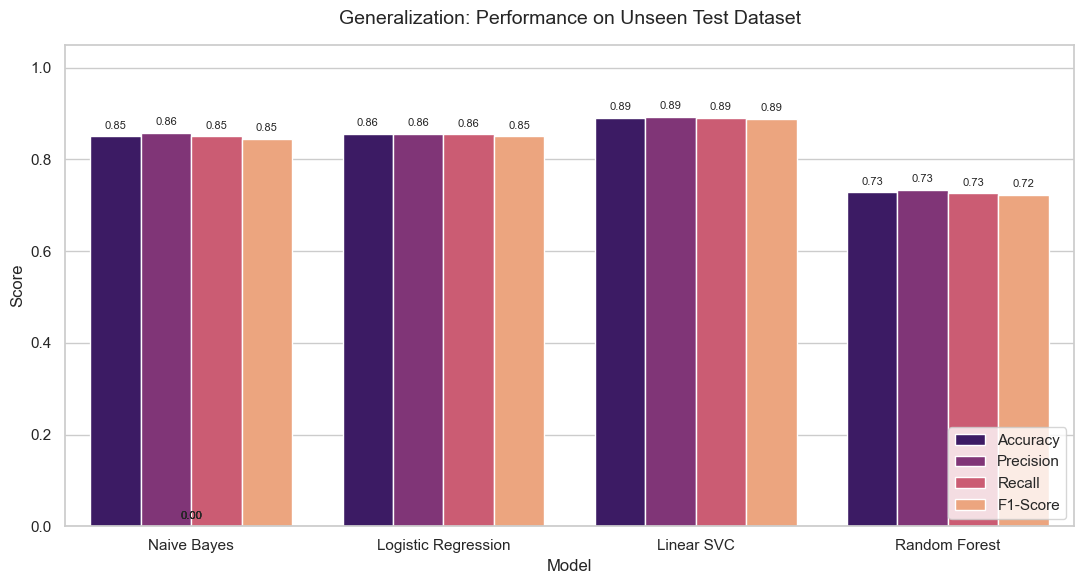

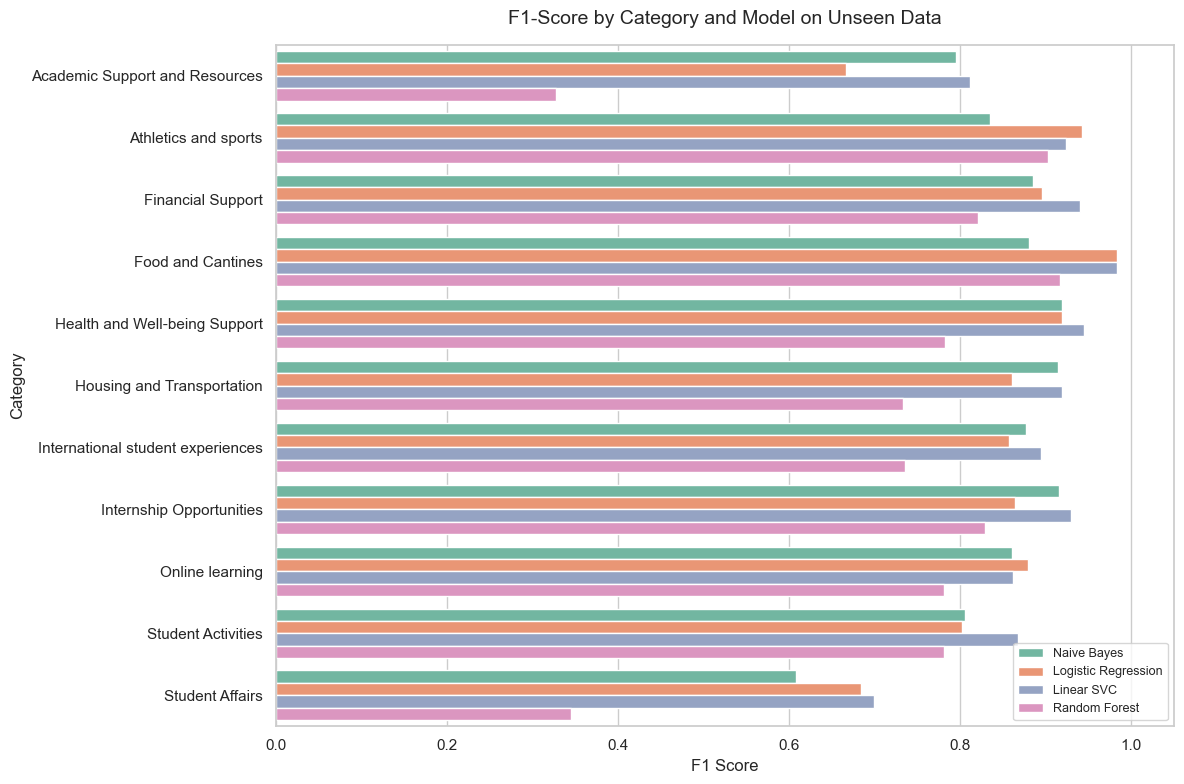

  PER-CATEGORY F1-SCORE — ALL MODELS
Model                              Linear SVC  Logistic Regression  Naive Bayes  Random Forest
Category                                                                                      
Academic Support and Resources         0.8111               0.6667       0.7953         0.3275
Athletics and sports                   0.9239               0.9430       0.8350         0.9029
Financial Support                      0.9399               0.8958       0.8851         0.8208
Food and Cantines                      0.9840               0.9840       0.8800         0.9167
Health and Well-being Support          0.9444               0.9189       0.9189         0.7821
Housing and Transportation             0.9195               0.8606       0.9140         0.7337
International student experiences      0.8950               0.8571       0.8776         0.7358
Internship Opportunities               0.9293               0.8638       0.9154         0.8288
Online learni

In [84]:
unseen_results = {}
unseen_per_class_reports = {}

for name, model in models.items():
    y_pred = model.predict(x_test_new)
    
    acc = accuracy_score(y_test_new, y_pred)
    prec = precision_score(y_test_new, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test_new, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test_new, y_pred, average='macro', zero_division=0)

    unseen_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

    report = classification_report(y_test_new, y_pred, output_dict=True)
    unseen_per_class_reports[name] = report

df_unseen_summary = pd.DataFrame(unseen_results).T.round(4)
df_unseen_summary.index.name = 'Model'

print("  UNSEEN TEST SET — RESULTS SUMMARY (ALL MODELS)")
print(df_unseen_summary.to_string())
print()

best_model_unseen = df_unseen_summary['F1-Score'].idxmax()
print(f"Best generalizing model: {best_model_unseen}  "
      f"(F1-Score = {df_unseen_summary.loc[best_model_unseen, 'F1-Score']})")

df_melted = df_unseen_summary.reset_index().melt(
    id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    var_name='Metric', value_name='Score'
)

plt.figure(figsize=(11, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='magma')
plt.title('Generalization: Performance on Unseen Test Dataset', fontsize=14, pad=15)
plt.ylim(0.0, 1.05)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}",
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', xytext=(0, 4),
                       textcoords='offset points', fontsize=8)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

classes = [c for c in list(unseen_per_class_reports.values())[0].keys()
           if c not in ('accuracy', 'macro avg', 'weighted avg')]

per_class_rows = []
for name, report in unseen_per_class_reports.items():
    for cls in classes:
        per_class_rows.append({
            'Model': name,
            'Category': cls,
            'F1-Score': report[cls]['f1-score']
        })

df_per_class = pd.DataFrame(per_class_rows)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_per_class, x='F1-Score', y='Category', hue='Model', palette='Set2')
plt.title('F1-Score by Category and Model on Unseen Data', fontsize=14, pad=15)
plt.xlim(0.0, 1.05)
plt.xlabel('F1 Score', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

df_per_class_pivot = df_per_class.pivot(index='Category', columns='Model', values='F1-Score').round(4)
print("  PER-CATEGORY F1-SCORE — ALL MODELS")
print(df_per_class_pivot.to_string())

In [85]:
def classify(complaint: str):
    """
    Classify a student complaint using Linear SVC (best model).
    Usage: classify("your complaint here")
    """
    if not complaint.strip():
        print("Please enter a complaint.")
        return

    pred = models["Linear SVC"].predict([complaint])[0]

    print()
    print("=" * 50)
    print("  YOUR COMPLAINT:")
    print(f"  {complaint}")
    print("-" * 50)
    print(f"  Predicted Category: {pred}")
    print("=" * 50)
    print()

classify("The gym isn't cleaned regularly.")
classify("My internship application isn't accepted yet.")
classify("My lecture rooom is very dirty.")
classify("My assignments can't be submitted on time due to app lag.")
classify("The library chair is broken for months now, why hasn't it been fixed yet?")


  YOUR COMPLAINT:
  The gym isn't cleaned regularly.
--------------------------------------------------
  Predicted Category: Athletics and sports


  YOUR COMPLAINT:
  My internship application isn't accepted yet.
--------------------------------------------------
  Predicted Category: Internship Opportunities


  YOUR COMPLAINT:
  My lecture rooom is very dirty.
--------------------------------------------------
  Predicted Category: Online learning


  YOUR COMPLAINT:
  My assignments can't be submitted on time due to app lag.
--------------------------------------------------
  Predicted Category: Online learning


  YOUR COMPLAINT:
  The library chair is broken for months now, why hasn't it been fixed yet?
--------------------------------------------------
  Predicted Category: Academic Support and Resources

